# Centralized Retrieval-Augmented Generation (RAG)

This notebook implements an improved Centralized RAG pipeline featuring:

- Optimized document chunking for fine-grained embeddings
- High-quality embedding model selection
- Enhanced retrieval with FAISS vector store
- Robust evaluation metrics (EM and F1 scores)
- Comprehensive visualization of results

The goal is to maximize retrieval accuracy and reduce hallucinations in QA tasks.

In [ ]:
# Install required packages
!pip install -qqq langchain faiss-cpu python-dotenv
!pip install -qqq -U langchain-openai
!pip install -qqq langchain-core langchain-openai langchain-community
!pip install -qqq matplotlib numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.3/31.3 MB 46.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.2/65.2 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 438.1/438.1 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.0/363.0 kB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 33.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.4/44.4 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 3.7 MB/s eta 0:00:00


In [ ]:
import os
import string
import numpy as np
import matplotlib.pyplot as plt
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_community.vectorstores import FAISS
from langchain.chains import RetrievalQA
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain.document_loaders import TextLoader
import warnings
warnings.filterwarnings("ignore")

In [ ]:
# Set OpenAI API Key
os.environ["OPENAI_API_KEY"] = "sk-F043ezHkcw1tw95X229M4wccKGjCFgatDGlsuTSWpST3BlbkFJQ6D6rEq7sbdjY3B8xIhdaN-6FNuVP2Xw7UE4F8fJwA"

# Initialize the LLM model
llm = ChatOpenAI(
    model_name="gpt-4o",
    temperature=0.0  # Lower temperature for more deterministic answers
)

# Initialize embeddings with a high-quality model
embeddings = OpenAIEmbeddings(model="text-embedding-3-small")

## Load and Process Data

In [ ]:
# Load the text data from the file
text_loader = TextLoader(file_path="./msc_ai_hullonline_short.txt")
documents = text_loader.load()

# Print the first few lines to verify content
print(f"Loaded {len(documents)} document(s)")
print("\nSample content:")
print(documents[0].page_content[:500], "...")

Loaded 1 document(s)

Sample content:
The MSc Artificial Intelligence Online is delivered 100% online.
The MSc Artificial Intelligence Online program takes two years to complete on a part-time basis.
The total cost of the the MSc Artificial Intelligence Online program is £8,950, with instalment and funding options available.
The start dates for the for the MSc Artificial Intelligence Online program are in January, May, and September.
Yes, the 30-week PGCert in Responsible Artificial Intelligence is available for those seeking a shor ...


In [ ]:
# Initialize the text splitter with optimized parameters
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=500,  # Smaller chunks for more precise retrieval
    chunk_overlap=100,  # Increased overlap to maintain context
    separators=["\n\n", "\n", ".", "!", "?", ";", ":", " ", ""],  # Prioritized separators
    length_function=len
)

# Split the documents into chunks
split_docs = text_splitter.split_documents(documents)
print(f"Created {len(split_docs)} document chunks")

# Display a sample chunk
print("\nSample chunk:")
print(split_docs[0].page_content)

Created 15 document chunks

Sample chunk:
The MSc Artificial Intelligence Online is delivered 100% online.
The MSc Artificial Intelligence Online program takes two years to complete on a part-time basis.
The total cost of the the MSc Artificial Intelligence Online program is £8,950, with instalment and funding options available.
The start dates for the for the MSc Artificial Intelligence Online program are in January, May, and September.


In [ ]:
# Initialize FAISS vector store and add documents
print("Building FAISS index...")
vector_store = FAISS.from_documents(split_docs, embeddings)
print("FAISS index built successfully")

Building FAISS index...
FAISS index built successfully


In [ ]:
# Create the retriever with optimized parameters
retriever = vector_store.as_retriever(
    search_type="similarity",  # Use similarity search
    search_kwargs={"k": 5}  # Retrieve top 5 most relevant chunks
)

# Build the RetrievalQA chain
qa_chain = RetrievalQA.from_chain_type(
    llm=llm,
    chain_type="stuff",  # Simple but effective for our use case
    retriever=retriever,
    return_source_documents=True,  # Return source documents for transparency
    verbose=False
)

## Evaluation Metrics

In [ ]:
def normalize(text: str) -> list:
    """
    Lowercase, strip punctuation, commas, and currency symbols, then split into tokens.
    """
    t = text.lower().replace(",", "").replace("£", "").replace("pounds", "")
    translator = str.maketrans("", "", string.punctuation)
    return t.translate(translator).split()

def exact_match(prediction: str, truth: str) -> int:
    """
    Return 1 if normalized truth matches normalized prediction exactly or as a subset.
    """
    npred = normalize(prediction)
    ntruth = normalize(truth)
    if ntruth == npred or set(ntruth).issubset(set(npred)):
        return 1
    return 0

def f1_score(prediction: str, truth: str) -> float:
    """
    Calculate F1 score between prediction and ground truth.
    """
    pred_tokens = normalize(prediction)
    truth_tokens = normalize(truth)

    common = set(pred_tokens) & set(truth_tokens)
    if not common:
        return 0.0

    precision = len(common) / len(pred_tokens)
    recall = len(common) / len(truth_tokens)

    if precision + recall == 0:
        return 0.0

    return 2 * (precision * recall) / (precision + recall)

In [ ]:
# Define evaluation questions and corresponding ground truth answers
questions = [
    "What is the total cost of the MSc Artificial Intelligence online programme at the University of Hull?",
    "How long does the MSc Artificial Intelligence online programme at the University of Hull take to complete?",
    "What is the phone number for enquiries about online courses at the University of Hull?",
    "What is the email address for enquiries about online courses at the University of Hull?",
    "When are the start dates for the MSc Artificial Intelligence online programme at the University of Hull?",
    "Who is the Programme Director for the MSc in Artificial Intelligence Online at the University of Hull?",
    "What language proficiency is required if my first language isn't English?",
    "Who are the lecturers for the MSc Artificial Intelligence program at the University of Hull?",
    "How can I pay my tuition online?",
    "What is the mode of delivery for the MSc Artificial Intelligence Online?",
]

ground_truths = [
    "The total cost of the MSc Artificial Intelligence online programme at the University of Hull is £8,950",
    "The MSc Artificial Intelligence online programme at the University of Hull takes 24 months (two years) to complete on a part-time basis",
    "The phone number for enquiries about online courses at the University of Hull is +44 (0)1482 251819",
    "The email address for enquiries about online courses at the University of Hull is enquiries-online@hull.ac.uk",
    "The start dates of the MSc Artificial Intelligence online programme at the University of Hull are January, May, and September",
    "The Programme Director for the MSc in Artificial Intelligence Online at the University of Hull is Dr. Rameez Kureshi",
    "An IELTS score of 6.0 (with a minimum of 5.5 in each skill) or an equivalent English language proficiency qualification is required",
    "The lecturers for the MSc Artificial Intelligence program at the University of Hull are Dr. Rameez Kureshi, Professor Adil Khan, Khadija Fraz, Dr. Bhupesh Mishra, Professor Dhaval Thakker",
    "To pay online, visit the Convera GlobalPay website after receiving your offer",
    "The MSc Artificial Intelligence Online is delivered 100% online"
]

## Run Evaluation

In [ ]:
# Run evaluation
predictions = []
em_scores = []
f1_scores = []
source_docs_list = []

# Make sure we only iterate up to the minimum length of both lists to avoid IndexError
min_length = min(len(questions), len(ground_truths))

for i in range(min_length):
    print(f"Question {i+1}: {questions[i]}")

    # Get response from QA chain
    response = qa_chain({"query": questions[i]})
    answer = response["result"]
    source_docs = response["source_documents"]

    # Store results
    predictions.append(answer)
    source_docs_list.append(source_docs)

    print(f"Prediction: {answer}")
    print(f"Ground Truth: {ground_truths[i]}")

    # Calculate metrics
    em = exact_match(answer, ground_truths[i])
    f1 = f1_score(answer, ground_truths[i])
    em_scores.append(em)
    f1_scores.append(f1)

    print(f"Exact Match: {em}, F1 Score: {f1:.2f}\n")

# Calculate average scores
avg_em = sum(em_scores) / len(em_scores)
avg_f1 = sum(f1_scores) / len(f1_scores)

print(f"Average Exact Match: {avg_em:.2f}")
print(f"Average F1 Score: {avg_f1:.2f}")

Question 1: What is the total cost of the MSc Artificial Intelligence online programme at the University of Hull?
Prediction: The total cost of the MSc Artificial Intelligence Online program at the University of Hull is £8,950.
Ground Truth: The total cost of the MSc Artificial Intelligence online programme at the University of Hull is £8,950
Exact Match: 0, F1 Score: 0.76

Question 2: How long does the MSc Artificial Intelligence online programme at the University of Hull take to complete?
Prediction: The MSc Artificial Intelligence Online program at the University of Hull takes two years to complete on a part-time basis.
Ground Truth: The MSc Artificial Intelligence online programme at the University of Hull takes 24 months (two years) to complete on a part-time basis
Exact Match: 0, F1 Score: 0.86

Question 3: What is the phone number for enquiries about online courses at the University of Hull?
Prediction: The phone number for enquiries about online courses at the University of Hul

## Visualize Results

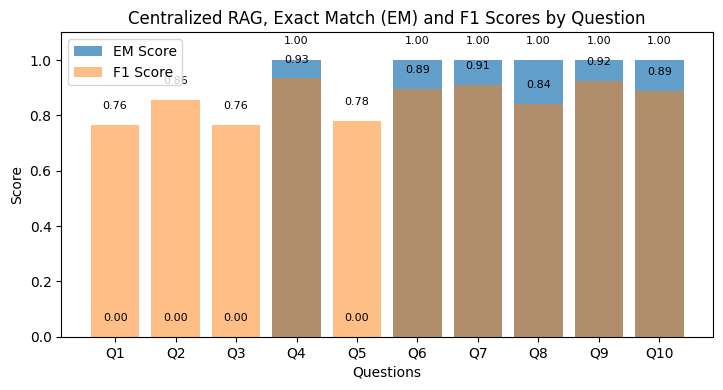

In [ ]:
# Visualize results
plt.figure(figsize=(14, 4))

# Plot individual scores
plt.subplot(1, 2, 1)
question_ids = [f"Q{i+1}" for i in range(len(em_scores))]
bars1 = plt.bar(question_ids, em_scores, alpha=0.7, label='EM Score')
bars2 = plt.bar(question_ids, f1_scores, alpha=0.5, label='F1 Score')
plt.ylim(0, 1.1)
plt.xlabel('Questions')
plt.ylabel('Score')
plt.title('Centralized RAG, Exact Match (EM) and F1 Scores by Question')
plt.legend()

# Add score values above each bar
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height + 0.05,
                f'{height:.2f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('Centralized RAG_em_f1_by_question.jpg', format='jpg', dpi=300) # Save as JPEG
plt.show()

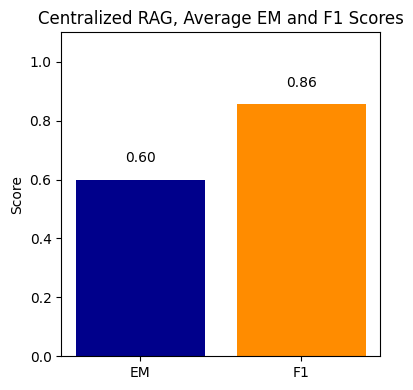

In [ ]:
#Plot average EM & F1 in a separate square figure
plt.figure(figsize=(4, 4))
bars3 = plt.bar(['EM', 'F1'], [avg_em, avg_f1], color=['darkblue', 'darkorange'])
plt.ylim(0, 1.1)
plt.ylabel('Score')
plt.title('Centralized RAG, Average EM and F1 Scores')
for bar in bars3:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, h + .05, f'{h:.2f}',
             ha='center', va='bottom')
plt.tight_layout()
plt.savefig('Centralized_RAG_em_f1_average.jpg', format='jpg', dpi=300) # Save as JPEG
plt.show()

## Streamlit App Code

Below is the code for a Streamlit app that implements this centralized RAG system. Save this to a file named `CentralizedRAG_ChatBot.py`.

In [ ]:
%%writefile CentralizedRAG_ChatBot.py

import streamlit as st
import os
import string
import time

from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain.chains import RetrievalQA
from langchain.document_loaders import TextLoader

# Set page configuration
st.set_page_config(
    page_title="Centralized RAG Chatbot",
    page_icon="🤖",
    layout="wide",
    initial_sidebar_state="expanded"
)

# Add custom CSS
st.markdown("""
<style>
    .main-header {
        font-size: 2.5rem;
        color: #1E88E5;
        text-align: center;
    }
    .sub-header {
        font-size: 1.5rem;
        color: #424242;
        text-align: center;
        margin-bottom: 2rem;
    }
    .source-header {
        font-size: 1.2rem;
        font-weight: bold;
        color: #1E88E5;
        margin-top: 1rem;
    }
    .source-text {
        background-color: #f0f2f6;
        padding: 1rem;
        border-radius: 0.5rem;
        margin-bottom: 1rem;
    }
</style>
""", unsafe_allow_html=True)

# Set OpenAI API key from Streamlit secrets or environment variable
def get_api_key():
    if 'OPENAI_API_KEY' in st.secrets:
        return st.secrets["OPENAI_API_KEY"]
    elif 'OPENAI_API_KEY' in os.environ:
        return os.environ["OPENAI_API_KEY"]
    else:
        return st.sidebar.text_input("Enter your OpenAI API key:", type="password")

api_key = get_api_key()
if api_key:
    os.environ["OPENAI_API_KEY"] = api_key
else:
    st.warning("Please enter your OpenAI API key to continue.")
    st.stop()

# Initialize session state for storing index and chat history
if 'initialized' not in st.session_state:
    st.session_state.initialized = False
    st.session_state.vector_store = None
    st.session_state.qa_chain = None
    st.session_state.chat_history = []

# Load the text data from the file
@st.cache_data(show_spinner=False)
def load_data():
    text_loader = TextLoader(file_path="./data/msc_ai_hullonline_short.txt")
    return text_loader.load()

# Main function to build the Streamlit app
def main():
    st.markdown("<h1 class='main-header'>Centralized RAG Chatbot</h1>", unsafe_allow_html=True)
    st.markdown("<h2 class='sub-header'>University of Hull MSc AI Online Program</h2>", unsafe_allow_html=True)

    # Sidebar for configuration
    st.sidebar.title("Configuration")

    # Initialize embeddings model
    embeddings_model = st.sidebar.selectbox(
        "Embeddings Model",
        ["text-embedding-3-small", "text-embedding-3-large"],
        index=0
    )

    # Initialize LLM model
    llm_model = st.sidebar.selectbox(
        "LLM Model",
        ["gpt-4o", "gpt-3.5-turbo"],
        index=0
    )

    # Temperature setting
    temperature = st.sidebar.slider("Temperature", 0.0, 1.0, 0.0, 0.1)

    # Number of documents to retrieve
    k_docs = st.sidebar.slider("Number of documents to retrieve", 3, 15, 5)

    # Chunk size and overlap
    chunk_size = st.sidebar.slider("Chunk Size", 300, 1000, 500, 50)
    chunk_overlap = st.sidebar.slider("Chunk Overlap", 50, 200, 100, 10)

    # Initialize button
    if not st.session_state.initialized:
        if st.sidebar.button("Initialize RAG System"):
            with st.spinner("Initializing RAG System..."):
                # Initialize embedding model
                embeddings = OpenAIEmbeddings(model=embeddings_model)

                # Progress bar for initialization
                progress_bar = st.progress(0)

                # Load documents
                st.sidebar.subheader("Loading documents...")
                progress_bar.progress(20)
                documents = load_data()

                # Split documents
                st.sidebar.subheader("Processing documents...")
                progress_bar.progress(40)
                text_splitter = RecursiveCharacterTextSplitter(
                    chunk_size=chunk_size,
                    chunk_overlap=chunk_overlap,
                    separators=["\n\n", "\n", ".", "!", "?", ";", ":", " ", ""],
                    length_function=len
                )
                split_docs = text_splitter.split_documents(documents)
                st.sidebar.write(f"Created {len(split_docs)} document chunks")
                progress_bar.progress(60)

                # Build FAISS index
                st.sidebar.subheader("Building FAISS index...")
                vector_store = FAISS.from_documents(split_docs, embeddings)
                progress_bar.progress(80)

                # Create retriever and QA chain
                retriever = vector_store.as_retriever(
                    search_type="similarity",
                    search_kwargs={"k": k_docs}
                )

                qa_chain = RetrievalQA.from_chain_type(
                    llm=ChatOpenAI(model_name=llm_model, temperature=temperature),
                    chain_type="stuff",
                    retriever=retriever,
                    return_source_documents=True,
                    verbose=False
                )

                # Store in session state
                st.session_state.vector_store = vector_store
                st.session_state.qa_chain = qa_chain
                st.session_state.initialized = True

                progress_bar.progress(100)
                st.sidebar.success("Initialization complete!")
                st.rerun()
    else:
        st.sidebar.success("System initialized and ready!")

        # Reset button
        if st.sidebar.button("Reset System"):
            st.session_state.initialized = False
            st.session_state.vector_store = None
            st.session_state.qa_chain = None
            st.session_state.chat_history = []
            st.rerun()

    # Main chat interface
    if st.session_state.initialized:
        # Display chat history
        for i, (question, answer, sources) in enumerate(st.session_state.chat_history):
            st.markdown(f"**You:** {question}")
            st.markdown(f"**AI:** {answer}")

            with st.expander("View Sources"):
                for source in sources:
                    st.markdown(f"<div class='source-header'>Source: {source.metadata['source']}</div>", unsafe_allow_html=True)
                    st.markdown(f"<div class='source-text'>{source.page_content[:500]}...</div>", unsafe_allow_html=True)

            st.markdown("---")

        # Input for new question
        user_question = st.text_input("Ask a question about the University of Hull MSc AI program:", key="question_input")

        col1, col2 = st.columns([1, 5])
        with col1:
            submit_button = st.button("Ask")

        if submit_button and user_question:
            with st.spinner("Generating response..."):
                # Initialize progress bar
                progress_bar = st.progress(0)

                # Simulate progress for the query process
                for percent_complete in range(1, 51):
                    time.sleep(0.02)  # Simulate retrieval delay
                    progress_bar.progress(percent_complete)

                # Get response from QA chain
                response = st.session_state.qa_chain({"query": user_question})
                answer = response["result"]
                sources = response["source_documents"]

                # Continue progress simulation
                for percent_complete in range(51, 101):
                    time.sleep(0.01)  # Simulate processing delay
                    progress_bar.progress(percent_complete)

                # Add to chat history
                st.session_state.chat_history.append((user_question, answer, sources))

                # Clear the input box and rerun to show the updated chat
                st.rerun()

if __name__ == "__main__":
    main()

Overwriting CentralizedRAG_ChatBot.py


## Requirements.txt

Create a requirements.txt file with the following content:

In [ ]:
%%writefile requirements.txt
streamlit
openai
langchain
langchain-core
langchain-openai
langchain-community
faiss-cpu
python-dotenv
matplotlib
numpy
beautifulsoup4
requests
sentence-transformers

Writing requirements.txt


# **Create Gradio App**

In [ ]:
%%writefile requirements.txt
gradio
openai
langchain
langchain-core
langchain-openai
langchain-community
faiss-cpu
python-dotenv
matplotlib
numpy
beautifulsoup4
requests
sentence-transformers

In [ ]:
%%writefile CentralizedRAG_ChatBot_g.py

import gradio as gr
import os
import string
import time
from typing import List, Tuple

from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain.chains import RetrievalQA
from langchain_community.document_loaders import TextLoader

# Global variables to store the RAG system components
vector_store = None
qa_chain = None
initialized = False
chat_history = []

# Custom CSS for bluish theme
custom_css = """
.gradio-container {
    max-width: 1200px !important;
    margin: auto !important;
    font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
}

.main-header {
    text-align: center;
    margin-bottom: 2rem;
    padding: 2rem;
    background: linear-gradient(135deg, #0891b2 0%, #1e40af 100%);
    border-radius: 15px;
    color: white;
    box-shadow: 0 8px 32px rgba(8, 145, 178, 0.3);
}

.main-title {
    font-size: 2.5rem;
    font-weight: 700;
    margin-bottom: 0.5rem;
    line-height: 1.2;
}

.sub-title {
    font-size: 1.2rem;
    opacity: 0.9;
    margin-bottom: 0;
}

.description {
    font-size: 1rem;
    color: #1e293b;
    margin: 2rem 0;
    padding: 1.5rem;
    background: linear-gradient(135deg, #f0f9ff 0%, #e0f2fe 100%);
    border-radius: 12px;
    border-left: 5px solid #0891b2;
    box-shadow: 0 4px 16px rgba(8, 145, 178, 0.1);
}

.chat-container {
    background: white;
    padding: 1.5rem;
    border-radius: 12px;
    margin: 1rem 0;
    box-shadow: 0 4px 16px rgba(8, 145, 178, 0.1);
    border-left: 4px solid #0891b2;
}

.question-text {
    font-weight: bold;
    color: #1e40af;
    margin-bottom: 0.5rem;
    font-size: 1.1rem;
}

.answer-text {
    color: #0f766e;
    line-height: 1.6;
    background: linear-gradient(135deg, #f0fdfa 0%, #ccfbf1 100%);
    padding: 1rem;
    border-radius: 8px;
    margin-top: 0.5rem;
}

.source-container {
    background: linear-gradient(135deg, #f8fafc 0%, #e2e8f0 100%);
    padding: 1rem;
    border-radius: 8px;
    margin: 0.5rem 0;
    border-left: 3px solid #64748b;
}

.info-box {
    background: linear-gradient(135deg, #eff6ff 0%, #dbeafe 100%);
    padding: 1.5rem;
    border-radius: 12px;
    border-left: 4px solid #3b82f6;
    margin: 1rem 0;
    color: #1e40af;
}

.stats-container {
    background: linear-gradient(135deg, #f0f9ff 0%, #e0f2fe 100%);
    padding: 1.5rem;
    border-radius: 12px;
    margin: 1rem 0;
    border: 1px solid #0891b2;
}

.gr-button-primary {
    background: linear-gradient(135deg, #0891b2 0%, #1e40af 100%) !important;
    border: none !important;
    border-radius: 8px !important;
    font-weight: 600 !important;
    padding: 12px 24px !important;
    transition: all 0.3s ease !important;
    color: white !important;
}

.gr-button-primary:hover {
    transform: translateY(-2px) !important;
    box-shadow: 0 8px 25px rgba(8, 145, 178, 0.4) !important;
}

.gr-button-secondary {
    background: linear-gradient(135deg, #64748b 0%, #475569 100%) !important;
    border: none !important;
    border-radius: 8px !important;
    font-weight: 500 !important;
    color: white !important;
}

.gr-textbox {
    border-radius: 8px !important;
    border: 2px solid #e2e8f0 !important;
    transition: all 0.3s ease !important;
}

.gr-textbox:focus {
    border-color: #0891b2 !important;
    box-shadow: 0 0 0 3px rgba(8, 145, 178, 0.1) !important;
}

.gr-slider {
    accent-color: #0891b2 !important;
}

.gr-dropdown {
    border-radius: 8px !important;
    border: 2px solid #e2e8f0 !important;
}

.gr-accordion {
    border-radius: 8px !important;
    border: 1px solid #e2e8f0 !important;
}

.footer-info {
    text-align: center;
    margin-top: 2rem;
    padding: 1.5rem;
    background: linear-gradient(135deg, #f1f5f9 0%, #e2e8f0 100%);
    border-radius: 12px;
    font-size: 0.9rem;
    color: #64748b;
    box-shadow: 0 4px 16px rgba(0,0,0,0.05);
}
"""

def load_data(file_path: str):
    """Load text data from file"""
    try:
        text_loader = TextLoader(file_path=file_path)
        return text_loader.load()
    except Exception as e:
        return None

def initialize_rag_system(api_key: str, embeddings_model: str, llm_model: str,
                         temperature: float, k_docs: int, chunk_size: int,
                         chunk_overlap: int, data_file_path: str, progress=gr.Progress()):
    """Initialize the RAG system with given parameters"""
    global vector_store, qa_chain, initialized

    if not api_key:
        return "❌ Please provide an OpenAI API key", "", ""

    try:
        # Set API key
        os.environ["OPENAI_API_KEY"] = api_key

        progress(0.1, desc="Setting up embeddings...")
        # Initialize embedding model
        embeddings = OpenAIEmbeddings(model=embeddings_model)

        progress(0.2, desc="Loading documents...")
        # Load documents
        documents = load_data(data_file_path)
        if not documents:
            return "❌ Failed to load documents. Check file path.", "", ""

        progress(0.4, desc="Processing documents...")
        # Split documents
        text_splitter = RecursiveCharacterTextSplitter(
            chunk_size=chunk_size,
            chunk_overlap=chunk_overlap,
            separators=["\n\n", "\n", ".", "!", "?", ";", ":", " ", ""],
            length_function=len
        )
        split_docs = text_splitter.split_documents(documents)

        progress(0.6, desc="Building FAISS index...")
        # Build FAISS index
        vector_store = FAISS.from_documents(split_docs, embeddings)

        progress(0.8, desc="Creating QA chain...")
        # Create retriever and QA chain
        retriever = vector_store.as_retriever(
            search_type="similarity",
            search_kwargs={"k": k_docs}
        )

        qa_chain = RetrievalQA.from_chain_type(
            llm=ChatOpenAI(model_name=llm_model, temperature=temperature),
            chain_type="stuff",
            retriever=retriever,
            return_source_documents=True,
            verbose=False
        )

        initialized = True
        progress(1.0, desc="Complete!")

        return (f"✅ RAG System initialized successfully!\n\n"
                f"📄 Processed {len(split_docs)} document chunks\n"
                f"🤖 Using {llm_model} with {embeddings_model}\n"
                f"🔍 Retrieving top {k_docs} relevant documents"), "", ""

    except Exception as e:
        return f"❌ Error initializing RAG system: {str(e)}", "", ""

def ask_question(question: str, progress=gr.Progress()):
    """Process a question through the RAG system"""
    global qa_chain, initialized, chat_history

    if not initialized or not qa_chain:
        return "❌ Please initialize the RAG system first.", "", ""

    if not question.strip():
        return "⚠️ Please enter a question.", "", ""

    try:
        progress(0.3, desc="Retrieving relevant documents...")
        # Get response from QA chain
        response = qa_chain({"query": question})
        answer = response["result"]
        sources = response["source_documents"]

        progress(0.8, desc="Generating response...")

        # Format sources
        sources_text = ""
        for i, source in enumerate(sources, 1):
            source_file = source.metadata.get('source', 'Unknown')
            content_preview = source.page_content[:300] + "..." if len(source.page_content) > 300 else source.page_content
            sources_text += f"**Source {i}:** {source_file}\n\n{content_preview}\n\n---\n\n"

        # Add to chat history
        chat_history.append((question, answer, sources))

        # Format chat history for display
        chat_display = ""
        for i, (q, a, _) in enumerate(chat_history, 1):
            chat_display += f"**Q{i}:** {q}\n\n**AI:** {a}\n\n---\n\n"

        progress(1.0, desc="Complete!")

        return answer, sources_text, chat_display

    except Exception as e:
        return f"❌ Error processing question: {str(e)}", "", ""

def clear_chat_history():
    """Clear the chat history"""
    global chat_history
    chat_history = []
    return "", "", ""

def get_example_question():
    """Return an example question"""
    examples = [
        "How long does the MSc Artificial Intelligence course take to complete?",
        "What is the total cost of the MSc Artificial Intelligence Online program?",
        "What is the minimum academic qualification required to apply?",
        "What language proficiency is required if my first language isn't English?",
        "What if I don't have a degree but have relevant professional experience?"
    ]
    import random
    return random.choice(examples)

def get_statistics():
    """Get chat statistics"""
    global chat_history
    if not chat_history:
        return "No questions asked yet."

    total_questions = len(chat_history)
    total_sources = sum(len(sources) for _, _, sources in chat_history)
    avg_sources = total_sources / total_questions if total_questions > 0 else 0

    return f"""📊 **Session Statistics**

🔢 **Total Questions:** {total_questions}
📚 **Total Sources Used:** {total_sources}
📈 **Average Sources per Question:** {avg_sources:.1f}
"""

# Create the Gradio interface
with gr.Blocks(css=custom_css, title="Centralized RAG Chatbot", theme=gr.themes.Soft()) as demo:
    # Header section
    gr.HTML("""
        <div class="main-header">
            <h1 class="main-title">🤖 Centralized RAG Chatbot</h1>
            <p class="sub-title">RETRIEVAL-AUGMENTED GENERATION</p>
            <p style="font-size: 1rem; opacity: 0.8;">Uses centralized approach to retrieve MSc AI program information and generates natural responses with advanced AI</p>
        </div>
    """)

    # Description section
    gr.HTML("""
        <div class="description">
            <p><strong>ℹ️ How it works:</strong> This RAG (Retrieval-Augmented Generation) system combines document retrieval
            with AI generation to provide accurate, contextual answers about the MSc AI Online program at the University of Hull.</p>
        </div>
    """)

    with gr.Row():
        # Left column - Configuration
        with gr.Column(scale=1):
            gr.Markdown("## ⚙️ Configuration")

            # API Key
            api_key = gr.Textbox(
                label="🔑 OpenAI API Key",
                type="password",
                placeholder="Enter your OpenAI API key...",
                value=os.environ.get("OPENAI_API_KEY", "")
            )

            # Model Settings
            with gr.Accordion("🤖 Model Settings", open=False):
                embeddings_model = gr.Dropdown(
                    choices=["text-embedding-3-small", "text-embedding-3-large"],
                    value="text-embedding-3-small",
                    label="Embeddings Model"
                )

                llm_model = gr.Dropdown(
                    choices=["gpt-4o", "gpt-3.5-turbo"],
                    value="gpt-4o",
                    label="LLM Model"
                )

                temperature = gr.Slider(
                    minimum=0.0,
                    maximum=1.0,
                    value=0.0,
                    step=0.1,
                    label="Temperature"
                )

            # Retrieval Settings
            with gr.Accordion("🔍 Retrieval Settings", open=False):
                k_docs = gr.Slider(
                    minimum=3,
                    maximum=15,
                    value=5,
                    step=1,
                    label="Documents to retrieve"
                )

            # Document Processing
            with gr.Accordion("📄 Document Processing", open=False):
                chunk_size = gr.Slider(
                    minimum=300,
                    maximum=1000,
                    value=500,
                    step=50,
                    label="Chunk Size"
                )

                chunk_overlap = gr.Slider(
                    minimum=50,
                    maximum=200,
                    value=100,
                    step=10,
                    label="Chunk Overlap"
                )

                data_file_path = gr.Textbox(
                    label="Data File Path",
                    value="./data/msc_ai_hullonline_short.txt",
                    placeholder="Path to text data file"
                )

            # Initialize button
            init_btn = gr.Button(
                "🚀 Initialize RAG System",
                variant="primary",
                size="lg"
            )

            # Status display
            status_display = gr.Markdown(
                "👆 Click Initialize to start!",
                elem_classes=["info-box"]
            )

        # Right column - Chat Interface
        with gr.Column(scale=2):
            gr.Markdown("## 💬 Chat Interface")

            # Question input
            with gr.Row():
                question_input = gr.Textbox(
                    label="Enter your question:",
                    placeholder="e.g., How long does the MSc Artificial Intelligence course take to complete?",
                    lines=2,
                    scale=4
                )
                ask_btn = gr.Button(
                    "Ask",
                    variant="primary",
                    size="lg",
                    scale=1
                )

            # Action buttons
            with gr.Row():
                example_btn = gr.Button("💡 Example Question", variant="secondary")
                clear_btn = gr.Button("🗑️ Clear History", variant="secondary")
                stats_btn = gr.Button("📈 Statistics", variant="secondary")

            # Response display
            answer_output = gr.Markdown(
                label="Answer:",
                visible=True
            )

            # Sources display
            with gr.Accordion("📚 Sources", open=False):
                sources_output = gr.Markdown()

            # Chat history
            with gr.Accordion("💬 Chat History", open=True):
                chat_output = gr.Markdown()

    # Sample questions section
    gr.HTML("""
        <div class="info-box">
            <h3>💡 Sample Questions You Could Ask:</h3>
            <ol>
                <li>How long does the MSc Artificial Intelligence course take to complete?</li>
                <li>What is the total cost of the MSc Artificial Intelligence Online program?</li>
                <li>What is the minimum academic qualification required to apply for the MSc Artificial Intelligence (Online) program?</li>
                <li>What if I don't have a degree but have relevant professional experience?</li>
                <li>What language proficiency is required if my first language isn't English?</li>
            </ol>
        </div>
    """)

    # Footer
    gr.HTML("""
        <div class="footer-info">
            <p>🎓 <strong>About:</strong> MSc Artificial Intelligence Online Program - University of Hull</p>
            <p>🤖 <strong>Powered by:</strong> OpenAI GPT & LangChain RAG Technology</p>
        </div>
    """)

    # Event handlers
    init_btn.click(
        fn=initialize_rag_system,
        inputs=[api_key, embeddings_model, llm_model, temperature, k_docs,
                chunk_size, chunk_overlap, data_file_path],
        outputs=[status_display, sources_output, chat_output],
        show_progress=True
    )

    ask_btn.click(
        fn=ask_question,
        inputs=[question_input],
        outputs=[answer_output, sources_output, chat_output],
        show_progress=True
    )

    question_input.submit(
        fn=ask_question,
        inputs=[question_input],
        outputs=[answer_output, sources_output, chat_output],
        show_progress=True
    )

    example_btn.click(
        fn=get_example_question,
        outputs=[question_input]
    )

    clear_btn.click(
        fn=clear_chat_history,
        outputs=[answer_output, sources_output, chat_output]
    )

    stats_btn.click(
        fn=get_statistics,
        outputs=[answer_output]
    )

# Launch the app
if __name__ == "__main__":
    demo.launch(
        server_name="0.0.0.0",
        server_port=7860,
        share=False,
        show_error=True
    )
